# Face recognition using CNN

### Reading the Face Images data

In [ ]:
# Deep Learning CNN model to recognize face

TrainingImagePath="C:/Users/Yuval/Downloads/VGG Dataset"

from keras.preprocessing.image import ImageDataGenerator

# Defining pre-processing transformations on raw images of training data
train_datagen = ImageDataGenerator(
        rescale=1./255,  # Scales the image data[0,255] between [0,1]
        shear_range=0.1, # Tilting the image by 10%
        zoom_range=0.1,  # Zoom the image by 10%
        horizontal_flip=True) # flip the image by 180 degrees

# Defining pre-processing transformations on raw images of validation data
validation_datagen = ImageDataGenerator(rescale=1./255)

# Generating the Training Data
training_set = train_datagen.flow_from_directory(
        TrainingImagePath,
        target_size=(64, 64),
        batch_size=32,
        class_mode='categorical')


# Generating the Testing Data
validation_set = validation_datagen.flow_from_directory(
        TrainingImagePath,
        target_size=(64, 64),
        batch_size=32,
        class_mode='categorical')

# Printing class labels for each face
validation_set.class_indices

Found 1364 images belonging to 3 classes.
Found 1364 images belonging to 3 classes.


{'Aayushi': 0, 'DEV': 1, 'Priyanshu': 2}

### Creating a list of faces and classes

In [ ]:
# Creating lookup table for all faces
# class_indices have the numeric tag for each face
TrainClasses=training_set.class_indices

# Storing the face and the numeric tag for future reference
ResultMap={}
for faceValue,faceName in zip(TrainClasses.values(),TrainClasses.keys()):
    ResultMap[faceValue]=faceName

# Saving the face map for future reference
import pickle
with open("ResultsMap.pkl", 'wb') as f:
    pickle.dump(ResultMap, f, pickle.HIGHEST_PROTOCOL)

print("Mapping of Face and its ID",ResultMap)

# The number of neurons for the output layer is equal to the number of faces
OutputNeurons=len(ResultMap)
print('\n The Number of output neurons: ', OutputNeurons)

Mapping of Face and its ID {0: 'Aayushi', 1: 'DEV', 2: 'Priyanshu'}

 The Number of output neurons:  3


### Creating the CNN model

In [ ]:
# Create CNN deep learning model 
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPool2D
from keras.layers import Flatten
from keras.layers import Dense

# Initializing the Convolutional Neural Network
classifier= Sequential()

# STEP-1 Convolution
# Adding the first layer of CNN
# we are using the format (64,64,3) because we are using TensorFlow backend
# It means 3 matrix of size (64X64) pixels representing Red, Green and Blue components of pixels

classifier.add(Convolution2D(filters=10, kernel_size=(3, 3), strides=(1, 1), input_shape=(64,64,3), activation='relu'))

# STEP-2 MAX Pooling
classifier.add(MaxPool2D(pool_size=(2,2)))

# ADDITIONAL LAYER of CONVOLUTION for better accuracy 
classifier.add(Convolution2D(filters=4, kernel_size=(5, 5), strides=(2, 2), activation='relu'))

classifier.add(MaxPool2D(pool_size=(2,2)))


# STEP-3 FLattening
classifier.add(Flatten())

# STEP-4 Fully Connected Neural Network
classifier.add(Dense(64, activation='relu'))

# Output layer
classifier.add(Dense(OutputNeurons, activation='softmax'))

# Compiling the CNN
classifier.compile(loss='categorical_crossentropy', optimizer = 'adam', metrics=["accuracy"])

In [4]:
classifier.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 10)        280       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 10)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 4)         1004      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 4)          0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 196)               0         
                                                                 
 dense (Dense)               (None, 64)                1

In [6]:
training_set.samples

1364

### Fitting the model

In [ ]:
import time
# Measuring the time taken by the model to train
StartTime=time.time()

# Starting the model training
history = classifier.fit(
    training_set,
    steps_per_epoch=8,
    epochs=60,
    validation_data=validation_set,
    validation_steps=4)


EndTime=time.time()
print("############### Total Time Taken: ", round((EndTime-StartTime)/60), 'Minutes #############')

Epoch 1/60
8/8 [==============================] - 37s 5s/step - loss: 1.0781 - accuracy: 0.3984 - val_loss: 1.0160 - val_accuracy: 0.5078
Epoch 2/60
8/8 [==============================] - 37s 5s/step - loss: 0.9977 - accuracy: 0.5820 - val_loss: 0.8981 - val_accuracy: 0.7734
Epoch 3/60
8/8 [==============================] - 47s 6s/step - loss: 0.8350 - accuracy: 0.7344 - val_loss: 0.7472 - val_accuracy: 0.8047
Epoch 4/60
8/8 [==============================] - 91s 12s/step - loss: 0.6440 - accuracy: 0.8867 - val_loss: 0.4814 - val_accuracy: 0.9688
Epoch 5/60
8/8 [==============================] - 92s 12s/step - loss: 0.3947 - accuracy: 0.9570 - val_loss: 0.2681 - val_accuracy: 1.0000
Epoch 6/60
8/8 [==============================] - 75s 10s/step - loss: 0.2125 - accuracy: 1.0000 - val_loss: 0.1363 - val_accuracy: 1.0000
Epoch 7/60
8/8 [==============================] - 58s 8s/step - loss: 0.0914 - accuracy: 1.0000 - val_loss: 0.0514 - val_accuracy: 1.0000
Epoch 8/60
8/8 [===============

### Saving the model

In [ ]:
# Saving the model
classifier.save("classifier2.pkl")

INFO:tensorflow:Assets written to: classifier2.pkl\assets


INFO:tensorflow:Assets written to: classifier2.pkl\assets


In [10]:
val_loss, val_accuracy = classifier.evaluate(validation_set)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")


43/43 [==============================] - 221s 5s/step - loss: 2.1752e-04 - accuracy: 1.0000
Validation Accuracy: 100.00%
Validation Loss: 0.0002


### Testing the model on a different face

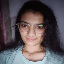

In [ ]:
import numpy as np
import tensorflow as tf

testImage = "C:/Users/Yuval/Downloads/WhatsApp Image 2025-10-15 at 23.52.27_11d11aa8.jpg"

test_image = tf.keras.utils.load_img(testImage, target_size=(64, 64))
test_image

In [ ]:
# Making predictions
print('### Converting the image into a numeric array ###')
test_image_array=tf.keras.utils.img_to_array(test_image)
print(test_image_array.shape,'\n')

print('### Reshaping the image array as one single sample for prediction ###')
test_image_array_exp_dim=np.expand_dims(test_image_array,axis=0)
print(test_image_array_exp_dim.shape, '\n')

# Generating probabilities for every face
result=classifier.predict(test_image_array_exp_dim,verbose=0)

print('### Printing probabilities for each class ###')
print(result, '\n')

print('### Printing original face mapping ###')
print(ResultMap, '\n')

print('####'*10)
print('Prediction: This is ',ResultMap[np.argmax(result)])

### Converting the image into a numeric array ###
(64, 64, 3) 

### Reshaping the image array as one single sample for prediction ###
(1, 64, 64, 3) 

### Printing probabilities for each class ###
[[1. 0. 0.]] 

### Printing original face mapping ###
{0: 'Aayushi', 1: 'DEV', 2: 'Priyanshu'} 

########################################
Prediction: This is  Aayushi


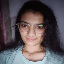

In [ ]:
import numpy as np
import tensorflow as tf

testImage = "C:/Users/Yuval/Downloads/WhatsApp Image 2025-10-15 at 23.52.27_11d11aa8.jpg"

test_image = tf.keras.utils.load_img(testImage, target_size=(64, 64))
test_image

In [ ]:
print('### Converting the image into a numeric array ###')
test_image_array=tf.keras.utils.img_to_array(test_image)
print(test_image_array.shape,'\n')

print('### Reshaping the image array as one single sample for prediction ###')
test_image_array_exp_dim=np.expand_dims(test_image_array,axis=0)
print(test_image_array_exp_dim.shape, '\n')

# Generating probabilities for every face
result=classifier.predict(test_image_array_exp_dim,verbose=0)

print('### Printing probabilities for each class ###')
print(result, '\n')

print('### Printing original face mapping ###')
print(ResultMap, '\n')

print('####'*10)
print('Prediction: This is ',ResultMap[np.argmax(result)])

### Converting the image into a numeric array ###
(64, 64, 3) 

### Reshaping the image array as one single sample for prediction ###
(1, 64, 64, 3) 

### Printing probabilities for each class ###
[[1. 0. 0.]] 

### Printing original face mapping ###
{0: 'Aayushi', 1: 'DEV', 2: 'Priyanshu'} 

########################################
Prediction: This is  Aayushi


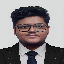

In [ ]:
import numpy as np
import tensorflow as tf

testImage = "C:/Users/Yuval/Downloads/DevFinaL.png"

test_image = tf.keras.utils.load_img(testImage, target_size=(64, 64))
test_image

In [ ]:
print('### Converting the image into a numeric array ###')
test_image_array=tf.keras.utils.img_to_array(test_image)
print(test_image_array.shape,'\n')

print('### Reshaping the image array as one single sample for prediction ###')
test_image_array_exp_dim=np.expand_dims(test_image_array,axis=0)
print(test_image_array_exp_dim.shape, '\n')

# Generating probabilities for every face
result=classifier.predict(test_image_array_exp_dim,verbose=0)

print('### Printing probabilities for each class ###')
print(result, '\n')

print('### Printing original face mapping ###')
print(ResultMap, '\n')

print('####'*10)
print('Prediction: This is ',ResultMap[np.argmax(result)])

### Converting the image into a numeric array ###
(64, 64, 3) 

### Reshaping the image array as one single sample for prediction ###
(1, 64, 64, 3) 

### Printing probabilities for each class ###
[[0. 1. 0.]] 

### Printing original face mapping ###
{0: 'Aayushi', 1: 'DEV', 2: 'Priyanshu'} 

########################################
Prediction: This is  DEV


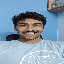

In [ ]:
import numpy as np
import tensorflow as tf

testImage = "c:/Users/Yuval/Downloads/WhatsApp Image 2025-10-16 at 01.05.10_a6d8c508.jpg"

test_image = tf.keras.utils.load_img(testImage, target_size=(64, 64))
test_image

In [ ]:
print('### Converting the image into a numeric array ###')
test_image_array=tf.keras.utils.img_to_array(test_image)
print(test_image_array.shape,'\n')

print('### Reshaping the image array as one single sample for prediction ###')
test_image_array_exp_dim=np.expand_dims(test_image_array,axis=0)
print(test_image_array_exp_dim.shape, '\n')

# Generating probabilities for every face
result=classifier.predict(test_image_array_exp_dim,verbose=0)

print('### Printing probabilities for each class ###')
print(result, '\n')

print('### Printing original face mapping ###')
print(ResultMap, '\n')

print('####'*10)
print('Prediction: This is ',ResultMap[np.argmax(result)])

### Converting the image into a numeric array ###
(64, 64, 3) 

### Reshaping the image array as one single sample for prediction ###
(1, 64, 64, 3) 

### Printing probabilities for each class ###
[[0. 0. 1.]] 

### Printing original face mapping ###
{0: 'Aayushi', 1: 'DEV', 2: 'Priyanshu'} 

########################################
Prediction: This is  Priyanshu


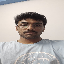

In [ ]:
import numpy as np
import tensorflow as tf

testImage = "c:/Users/Yuval/Downloads/WhatsApp Image 2025-10-15 at 23.43.03_dc50f4e9.jpg"

test_image = tf.keras.utils.load_img(testImage, target_size=(64, 64))
test_image

In [ ]:
print('### Converting the image into a numeric array ###')
test_image_array=tf.keras.utils.img_to_array(test_image)
print(test_image_array.shape,'\n')

print('### Reshaping the image array as one single sample for prediction ###')
test_image_array_exp_dim=np.expand_dims(test_image_array,axis=0)
print(test_image_array_exp_dim.shape, '\n')

# Generating probabilities for every face
result=classifier.predict(test_image_array_exp_dim,verbose=0)

print('### Printing probabilities for each class ###')
print(result, '\n')

print('### Printing original face mapping ###')
print(ResultMap, '\n')

print('####'*10)
print('Prediction: This is ',ResultMap[np.argmax(result)])

### Converting the image into a numeric array ###
(64, 64, 3) 

### Reshaping the image array as one single sample for prediction ###
(1, 64, 64, 3) 

### Printing probabilities for each class ###
[[0. 0. 1.]] 

### Printing original face mapping ###
{0: 'Aayushi', 1: 'DEV', 2: 'Priyanshu'} 

########################################
Prediction: This is  Priyanshu


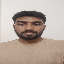

In [25]:
import numpy as np
import tensorflow as tf

testImage = "c:/Users/Yuval/Downloads/WhatsApp Image 2025-12-02 at 11.26.07 PM.jpeg"

test_image = tf.keras.utils.load_img(testImage, target_size=(64, 64))
test_image

In [26]:
print('### Converting the image into a numeric array ###')
test_image_array=tf.keras.utils.img_to_array(test_image)
print(test_image_array.shape,'\n')

print('### Reshaping the image array as one single sample for prediction ###')
test_image_array_exp_dim=np.expand_dims(test_image_array,axis=0)
print(test_image_array_exp_dim.shape, '\n')

# Generating probabilities for every face
result=classifier.predict(test_image_array_exp_dim,verbose=0)

print('### Printing probabilities for each class ###')
print(result, '\n')

print('### Printing original face mapping ###')
print(ResultMap, '\n')

print('####'*10)
print('Prediction: This is ',ResultMap[np.argmax(result)])

### Converting the image into a numeric array ###
(64, 64, 3) 

### Reshaping the image array as one single sample for prediction ###
(1, 64, 64, 3) 

### Printing probabilities for each class ###
[[0. 0. 1.]] 

### Printing original face mapping ###
{0: 'Aayushi', 1: 'DEV', 2: 'Priyanshu'} 

########################################
Prediction: This is  Priyanshu
